C:\Users\fs\AppData\Local\Temp\ipykernel_31324\945402482.py:289: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


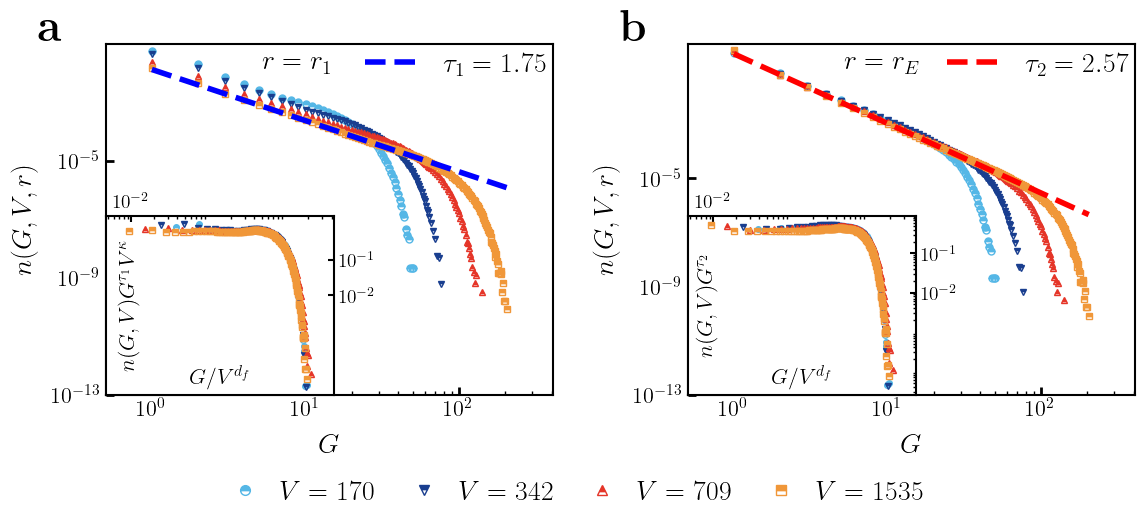

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
from matplotlib.ticker import LogFormatterMathtext
import matplotlib.patches as patches 
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D


def Axset(ax, ax1):

    ax.set_xscale('log')
    ax.set_yscale('log')
    # 设置主刻度
    ax.tick_params(axis='x', which='major', direction='in', width=2, length=6, colors='black', labelsize=16)
    ax.tick_params(axis='y', which='major', direction='in', width=2, length=6, colors='black', labelsize=16)
    # 设置次刻度
    ax.tick_params(axis='x', which='minor', direction='in', width=1, length=3, colors='black')
    ax.tick_params(axis='y', which='minor', direction='in', width=1, length=3, colors='black')
    
    # 设置坐标轴标签
    ax.set_xlabel('$G$', fontsize=20, labelpad=10)
    ax.set_ylabel('$n(G,V,r)$', fontsize=20, labelpad=10)

    xmin = 1e12; xmax = 1e-12; ymin = 1e12; ymax = 1e-12

    ax1.set_xscale('log') 
    ax1.set_yscale('log')

    # 设置子图刻度在顶部和右侧
    ax1.tick_params(axis='x', which='major', direction='in', width=1.5, length=4, colors='black', 
                    labelsize=14, labeltop=True, top=True, bottom=False, labelbottom=False)
    ax1.tick_params(axis='y', which='major', direction='in', width=1.5, length=4, colors='black', 
                    labelsize=14, labelright=True, right=True, left=False, labelleft=False)
    ax1.tick_params(axis='x', which='minor', direction='in', width=1, length=2, colors='black', 
                    top=True, bottom=False)
    ax1.tick_params(axis='y', which='minor', direction='in', width=1, length=2, colors='black', 
                    right=True, left=False)

    return



def PlotCri(ax, ax1, File1Arr):
    # 设置子图标签
    ax1.set_xlabel('$G/V^{d_f}$', fontsize=16, labelpad=-25)
    ax1.xaxis.set_label_position('bottom')
    ax1.set_ylabel('$n(G,V)G^{\\tau_1}V^{\\kappa}$', fontsize=16, labelpad=-25)
    ax1.yaxis.set_label_position('left')

    xmin = 1e12; xmax = 1e-12; ymin = 1e12; ymax = 1e-12
    xsmin = 1e12; xsmax = 1e-12; ysmin = 1e12; ysmax = 1e-12

    # 绘制主图数据
    for k in range(len(File1Arr)):
        fname1 = File1Arr[k]; L1 = SysSizeArr[k]; V1 = L1
        try:
            df1 = pd.read_csv(fname1, sep=r"\s+", skiprows=1, header=None) 
            da1 = np.array(df1)
            x1 = da1[:,1]; y1 = da1[:,3]

            x1min = min(x1); x1max = max(x1); y1min = min(y1); y1max = max(y1)
            xmin = min(xmin, x1min)
            xmax = max(xmax, x1max)
            ymin = min(ymin, y1min)
            ymax = max(ymax, y1max)

            ax.plot(x1, y1, color=ColorArr[k], 
                    marker=MarkerArr[k], markersize=MarSizArr[k], markerfacecolor=ColorArr[k],
                    fillstyle='top', markeredgewidth=1, markeredgecolor=ColorArr[k],  
                    linestyle='', label=f'_nolegend_')
            
            if L1 == 1535:
                amp = y1[20]*x1[20]**Tau1
                yT = amp/x1**Tau1 
                ax.plot(x1, yT, color="blue", linestyle='--', linewidth=4, label=f"$\\tau_1={Tau1S}$")
            
            # 子图数据变换
            x1s = [x11/V1**DF for x11 in x1]
            y1s = [y1[i1]*x1[i1]**Tau1*V1**Kappa for i1 in range(len(x1))]

            x1smin = min(x1s); x1smax = max(x1s); y1smin = min(y1s); y1smax = max(y1s)
            xsmin = min(xsmin, x1smin)
            xsmax = max(xsmax, x1smax)
            ysmin = min(ysmin, y1smin)
            ysmax = max(ysmax, y1smax)

            ax1.plot(x1s, y1s, color=ColorArr[k], 
                    marker=MarkerArr[k], markersize=MarSizArr[k]-1, markerfacecolor=ColorArr[k],
                    fillstyle='top', markeredgewidth=1, markeredgecolor=ColorArr[k],  
                    linestyle='', label=f'_nolegend_')

        except Exception as e:
            print(f"can not read file {fname1} with error: {e}")


    return  [xmin, xmax, ymin, ymax, xsmin, xsmax, ysmin, ysmax]

def PlotSup(ax, ax1, File1Arr):

    # 设置子图标签
    ax1.set_xlabel('$G/V^{d_f}$', fontsize=16, labelpad=-25)
    ax1.xaxis.set_label_position('bottom')
    ax1.set_ylabel('$n(G,V)G^{\\tau_2}$', fontsize=16, labelpad=-25)
    ax1.yaxis.set_label_position('left')

    xmin = 1e12; xmax = 1e-12; ymin = 1e12; ymax = 1e-12
    xsmin = 1e12; xsmax = 1e-12; ysmin = 1e12; ysmax = 1e-12

    # 绘制主图数据
    for k in range(len(File1Arr)):
        fname1 = File1Arr[k]; L1 = SysSizeArr[k]; V1 = L1
        try:
            df1 = pd.read_csv(fname1, sep=r"\s+", skiprows=1, header=None) 
            da1 = np.array(df1)
            x1 = da1[:,1]; y1 = da1[:,3]

            x1min = min(x1); x1max = max(x1); y1min = min(y1); y1max = max(y1)
            xmin = min(xmin, x1min)
            xmax = max(xmax, x1max)
            ymin = min(ymin, y1min)
            ymax = max(ymax, y1max)

            ax.plot(x1, y1, color=ColorArr[k], 
                    marker=MarkerArr[k], markersize=MarSizArr[k], markerfacecolor=ColorArr[k],
                    fillstyle='top', markeredgewidth=1, markeredgecolor=ColorArr[k],  
                    linestyle='', label=f'_nolegend_')
            
            if L1 == 1535:
                amp = y1[20]*x1[20]**Tau2
                yT = amp/x1**Tau2 
                ax.plot(x1, yT, color="red", linestyle='--', linewidth=4, 
                       label=f"$\\tau_2={Tau2S}$")
            
            # 子图数据变换
            x1s = [x11/V1**DF for x11 in x1]
            y1s = [y1[i1]*x1[i1]**Tau2 for i1 in range(len(x1))]

            x1smin = min(x1s); x1smax = max(x1s); y1smin = min(y1s); y1smax = max(y1s)
            xsmin = min(xsmin, x1smin)
            xsmax = max(xsmax, x1smax)
            ysmin = min(ysmin, y1smin)
            ysmax = max(ysmax, y1smax)

            ax1.plot(x1s, y1s, color=ColorArr[k], 
                    marker=MarkerArr[k], markersize=MarSizArr[k]-1, markerfacecolor=ColorArr[k],
                    fillstyle='top', markeredgewidth=1, markeredgecolor=ColorArr[k],  
                    linestyle='', label=f'_nolegend_')

        except Exception as e:
            print(f"can not read file {fname1} with error: {e}")

    return  [xmin, xmax, ymin, ymax, xsmin, xsmax, ysmin, ysmax]


# Figure setting  
plt.rcParams['text.usetex'] = True 
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({'font.size': 24})  # 稍微减小字体以适应多子图
figsize = (12, 5)  # 增大图形尺寸
ColorArr =["#55B7E6", "#193E8F", "#E53528", "#F09739"]
MarkerArr = ['o', 'v', '^', 's', 'D']
MarSizArr = [5, 5, 5, 5, 5]  # 稍微减小标记大小

# inset figure setting 
sub_width   = 0.25 
sub_height  = 0.12
left_shift  =-0.0285
bottom_shift =-0.0065
    
# Read File 
Curdir = os.getcwd() 
str0 = [str(k) for k in range(1,7)]
Tau2  =  2.57
DF    =  1.0/(Tau2-1)
Tau2S = "2.57"
Tau1  = 1.75
Kappa =  (Tau2 - Tau1)/ (Tau2-1)
Tau1S = "1.75" 

LabelArr   = [1900, 1919, 1938, 1952]
SysSizeArr = [170,  342, 709, 1535]
Frac =['$r=r_1$','$r=r_E$']

# 创建4×2的子图布局
fig, axes = plt.subplots(1, 2, figsize=figsize)


path1  = os.path.join(Curdir, f"../data0/")
DatDir = os.path.normpath(path1) 
for k in range(1,3):
    str1 = f"ns{k}.HisDc1_F"
    File1Arr = [os.path.join(DatDir, str1 + str(s1)) for s1 in LabelArr]

    ax = axes[k-1] 
    ax1 = inset_axes(ax, width="51%", height="51%", loc="lower left", 
                 bbox_to_anchor=(0,0,1,1), bbox_transform=ax.transAxes, borderpad=0)
    Axset(ax, ax1)

    if k ==1 : 
        xyM = PlotCri(ax, ax1, File1Arr)
    else :
        xyM = PlotSup(ax, ax1, File1Arr)


    xmin, xmax, ymin, ymax, xsmin, xsmax, ysmin, ysmax = xyM

    # 设置主图范围
    fac1 = 0.5; fac2 = 0.6
#    if k <=2:
#        fac1 = 0.8; fac2 = 0.9

    ax.set_xlim(fac1*xmin, 1.0/fac1*xmax)
    ax.set_ylim(fac2*ymin, 1.0/fac2*ymax)
    
    if k == 1:
        ax.set_xticks([1e0, 1e1, 1e2])
        ax.set_yticks([1e-5, 1e-9, 1e-13])
        ax1.set_xticks([1e-4, 1e-2])
        ax1.set_yticks([1e-2, 1e-1])

    if k == 2:
        ax.set_xticks([1e0, 1e1, 1e2])
        ax.set_yticks([1e-5, 1e-9, 1e-13])
        ax1.set_xticks([1e-4, 1e-2])
        ax1.set_yticks([1e-2, 1e-1])

#    if k <= 3:
#        ax.set_xticks([1e0, 1e2, 1e4, 1e6])
#        ax.set_yticks([1e-5, 1e-9, 1e-13])
#        ax1.set_xticks([1e-6, 1e-3])
#        ax1.set_yticks([1e-1, 1e-3])

#    if k > 3:
#        ax.set_xticks([1e0, 1e2, 1e4, 1e6])
#        ax.set_yticks([1e-5, 1e-9, 1e-13])
#        ax1.set_xticks([1e-6, 1e-3])
#        ax1.set_yticks([1e-1, 1e-3])
   

    # 添加主图图例（无标签艺术家），使用空句柄/标签以抑制警告
    leg = ax.legend(loc='upper right', bbox_to_anchor=(1.04, 1.05), fontsize=20, frameon=False, framealpha=0.9)

    locx= 0.35 
    ax.text(locx, 0.95, Frac[k-1], transform=ax.transAxes, 
            fontsize=20, fontweight='bold', 
            verticalalignment='center', horizontalalignment='left')

    label_text = chr(96 + k)
    ax.text(-0.15, 1.10, r'$\mathbf{' + label_text +'}$', transform=ax.transAxes, 
            fontsize=32, fontweight='bold', 
            verticalalignment='top', horizontalalignment='left')
    


    # 设置子图范围
    ax1.set_xlim(fac1*xsmin, 1.0/fac1*xsmax)
    ax1.set_ylim(fac2*ysmin, 1.0/fac2*ysmax)

    # 增强边框视觉效果
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    for spine in ax1.spines.values():
        spine.set_linewidth(1.5)


# 创建图例元素
legend_elements = [Line2D([0], [0], marker=MarkerArr[k], color=ColorArr[k], 
                   markerfacecolor=ColorArr[k], markersize=MarSizArr[k] + 2,  # 稍微增大图例中的标记大小
                   fillstyle='top', markeredgewidth=1, markeredgecolor=ColorArr[k], 
                   linestyle='None', label=f'$V={SysSizeArr[k]}$') for k in range(len(SysSizeArr))]

# 将图例放在图的最下面，横向排列
fig.legend(handles=legend_elements,
           loc='lower center',           # 放在底部中央
           bbox_to_anchor=(0.5, -0.12),   # 调整垂直位置
           ncol=5,                       # 横向排列，5列
           fontsize=20,                  # 图例字体大小
           frameon=False,                 # 显示图例框
           fancybox=True,                # 圆角边框
           shadow=False,                 # 无阴影
           handletextpad=0.5,            # 标记和文本间距
           columnspacing=1.0,            # 列间距
           handlelength=1.5)             # 标记长度

#plt.tight_layout(pad=1.0, w_pad=1.0, h_pad=1.0)
plt.tight_layout()
plt.subplots_adjust(bottom=0.15)  # 增加底部边距，为图例留出空间
plt.savefig("Fig5.pdf", bbox_inches='tight')
plt.show()

